In [1]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv("data.csv", encoding="latin1")


/tmp/ipython-input-2840565145.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv", encoding="latin1")


In [10]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [11]:
x=df['no2'].dropna().values

In [12]:
r=102317126
ar = 0.05 * (r % 7)
br = 0.3 * ((r % 5) + 1)
z = x + ar * np.sin(br * x)

In [14]:
mean_1= np.mean(z)
variance=np.var(z)
lambda1= 1 / (2 * variance)
c = np.sqrt(lambda1 / np.pi)

In [15]:
print("mu",mean_1)
print("lambda",lambda1)
print("c",c)

mu 25.810838442217115
lambda 0.0014605237358096261
c 0.021561519986176458


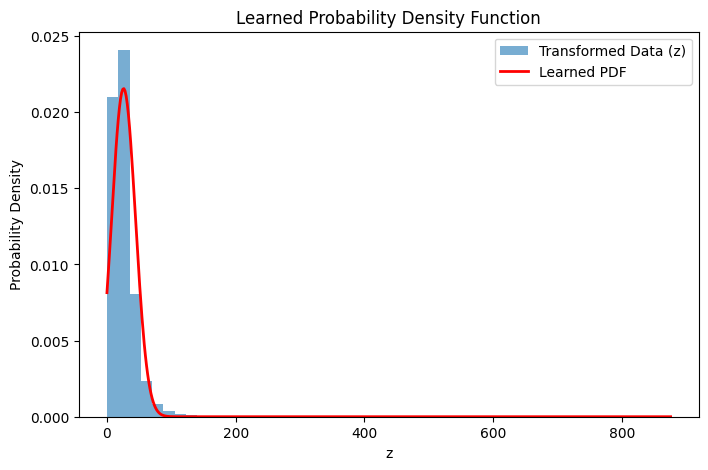

In [16]:
import matplotlib.pyplot as plt
zrange = np.linspace(z.min(), z.max(), 500)
pdf = c * np.exp(-lambda1 * (zrange - mean_1) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(z, bins=50, density=True, alpha=0.6, label="Transformed Data (z)")
plt.plot(zrange, pdf, 'r', linewidth=2, label="Learned PDF")
plt.xlabel("z")
plt.ylabel("Probability Density")
plt.legend()
plt.title("Learned Probability Density Function")
plt.show()